# 08 Final Comparison and Report

This notebook consolidates artifacts from notebooks **03-07** into a final, course-ready narrative.

It does four things end-to-end:
1. validates that all required upstream artifacts exist,
2. builds a unified comparison table across classical baselines, LSTM, XGBoost, rolling backtest, and uncertainty coverage,
3. produces polished summary figures,
4. exports final report markdown files under `results/final/`.


## Evaluation framing

To keep comparisons honest:
- **Primary model winner** is chosen on the shared held-out test window used in model notebooks (`2020-12` to `2026-01`).
- Rolling backtest and uncertainty results are treated as **robustness diagnostics**, not a direct replacement for the primary hold-out benchmark.
- Ablation outputs are used to discuss sensitivity (especially target definition and lag choices), not to overwrite the main benchmark protocol.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import json
import shutil
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown, Image

ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.project_utils import ensure_project_dirs, seed_everything

seed_everything(42)
paths = ensure_project_dirs()

final_dir = paths["results"] / "final"
fig_dir = final_dir / "figures"
final_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="talk")
pd.options.display.max_columns = 200

print("Repo root:", ROOT)
print("Final report dir:", final_dir)
print("Figure dir:", fig_dir)


Repo root: C:\Users\User\Downloads\261-Project
Final report dir: C:\Users\User\Downloads\261-Project\results\final
Figure dir: C:\Users\User\Downloads\261-Project\results\final\figures


## 1) Artifact manifest and strict existence checks

In [2]:
ARTIFACTS = {
    # Classical baselines
    "baseline_metrics": paths["results"] / "baselines" / "baseline_metrics.json",
    "baseline_plot": paths["results"] / "baselines" / "best_baseline_actual_vs_pred.png",

    # LSTM
    "lstm_metrics": paths["results"] / "lstm" / "metrics.json",
    "lstm_plot": paths["results"] / "lstm" / "preds_vs_actuals.png",

    # XGBoost
    "xgb_metrics": paths["results"] / "xgb" / "metrics.json",
    "xgb_plot": paths["results"] / "xgb" / "preds_vs_actuals.png",
    "xgb_feature_importance_plot": paths["results"] / "xgb" / "feature_importance.png",

    # Backtest + uncertainty
    "backtest_metrics": paths["results"] / "backtest" / "backtest_metrics.json",
    "uncertainty_coverage": paths["results"] / "uncertainty" / "coverage.json",
    "uncertainty_plot": paths["results"] / "uncertainty" / "uncertainty_plot.png",

    # Ablation
    "ablation_results": paths["results"] / "ablations" / "ablation_results.csv",
    "ablation_summary": paths["results"] / "ablations" / "ablation_summary.md",
}

artifact_df = pd.DataFrame([
    {"artifact": name, "path": str(path.relative_to(ROOT)), "exists": path.exists()}
    for name, path in ARTIFACTS.items()
]).sort_values("artifact").reset_index(drop=True)

display(artifact_df)

missing = artifact_df.loc[~artifact_df["exists"], "artifact"].tolist()
if missing:
    missing_text = ", ".join(missing)
    raise FileNotFoundError(
        "Missing required upstream artifacts for notebook 08: "
        f"{missing_text}. Run notebooks 03-07 before this final report notebook."
    )

print("All required upstream artifacts are present.")


,artifact,path,exists
0,ablation_results,results\ablations\ablation_results.csv,True
1,ablation_summary,results\ablations\ablation_summary.md,True
2,backtest_metrics,results\backtest\backtest_metrics.json,True
3,baseline_metrics,results\baselines\baseline_metrics.json,True
4,baseline_plot,results\baselines\best_baseline_actual_vs_pred...,True
5,lstm_metrics,results\lstm\metrics.json,True
6,lstm_plot,results\lstm\preds_vs_actuals.png,True
7,uncertainty_coverage,results\uncertainty\coverage.json,True
8,uncertainty_plot,results\uncertainty\uncertainty_plot.png,True
9,xgb_feature_importance_plot,results\xgb\feature_importance.png,True


All required upstream artifacts are present.


## 2) Load upstream metrics/artifacts

In [3]:
def read_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))

baseline_payload = read_json(ARTIFACTS["baseline_metrics"])
lstm_payload = read_json(ARTIFACTS["lstm_metrics"])
xgb_payload = read_json(ARTIFACTS["xgb_metrics"])
backtest_payload = read_json(ARTIFACTS["backtest_metrics"])
coverage_payload = read_json(ARTIFACTS["uncertainty_coverage"])
ablation_df = pd.read_csv(ARTIFACTS["ablation_results"]).sort_values("test_mae").reset_index(drop=True)

baseline_df = pd.DataFrame(baseline_payload["metrics"]).sort_values("mae").reset_index(drop=True)
backtest_windows_df = pd.DataFrame(backtest_payload.get("window_metrics", [])).copy()

best_baseline = baseline_df.iloc[0].to_dict()
best_ablation = ablation_df.iloc[0].to_dict()

print("Best classical baseline:", best_baseline["model"])
print("Best ablation run:", best_ablation["run_id"])
print("Ablation target mode:", best_ablation["target_mode"])

display(baseline_df[["model", "mae", "smape", "mase"]])


Best classical baseline: NaiveLast
Best ablation run: A9
Ablation target mode: mom


,model,mae,smape,mase
0,NaiveLast,0.340550,8.481803,1.250964
1,Lasso[flattened],1.044402,21.990918,3.836468
2,SeasonalNaive,2.543939,58.714027,9.344813
3,"ARIMA(1,0,0)",2.553635,64.992298,9.380430
4,Ridge[flattened],3.991319,115.498733,14.661564


## 3) Final comparison table (all required groups)

The table below combines:
- classical baseline winner,
- LSTM hold-out test,
- XGBoost hold-out test,
- XGBoost rolling backtest overall summary,
- LSTM uncertainty coverage summaries (MC-dropout and conformal).


In [4]:
comparison_rows = [
    {
        "section": "Classical baselines",
        "entry": str(best_baseline["model"]),
        "mae": float(best_baseline["mae"]),
        "smape": float(best_baseline["smape"]),
        "mase": float(best_baseline["mase"]),
        "coverage": np.nan,
        "avg_interval_width": np.nan,
        "evaluation_window": f"{baseline_payload['test_start']} to {baseline_payload['test_end']}",
        "notes": "Best row in baseline_metrics.json (naive, seasonal naive, ARIMA, Ridge, Lasso pool).",
    },
    {
        "section": "LSTM",
        "entry": str(lstm_payload.get("model_name", "stacked_lstm_nowcaster")),
        "mae": float(lstm_payload["metrics_test"]["mae"]),
        "smape": float(lstm_payload["metrics_test"]["smape"]),
        "mase": float(lstm_payload["metrics_test"]["mase"]),
        "coverage": np.nan,
        "avg_interval_width": np.nan,
        "evaluation_window": f"{lstm_payload['data']['test_start']} to {lstm_payload['data']['test_end']}",
        "notes": f"Stacked sequence model; lag={int(lstm_payload['config']['lag_length'])}.",
    },
    {
        "section": "XGBoost",
        "entry": f"selected={xgb_payload['selected_representation']}",
        "mae": float(xgb_payload["selected_representation_metrics"]["test"]["mae"]),
        "smape": float(xgb_payload["selected_representation_metrics"]["test"]["smape"]),
        "mase": float(xgb_payload["selected_representation_metrics"]["test"]["mase"]),
        "coverage": np.nan,
        "avg_interval_width": np.nan,
        "evaluation_window": f"{xgb_payload['data']['test_start']} to {xgb_payload['data']['test_end']}",
        "notes": f"Tabular model with {xgb_payload['selected_representation']} representation.",
    },
    {
        "section": "Rolling backtest summary",
        "entry": f"XGBoost walk-forward ({backtest_payload['n_windows']} windows)",
        "mae": float(backtest_payload["overall"]["mae"]),
        "smape": float(backtest_payload["overall"]["smape"]),
        "mase": float(backtest_payload["overall"]["mase"]),
        "coverage": np.nan,
        "avg_interval_width": np.nan,
        "evaluation_window": f"{backtest_windows_df['test_start'].min()} to {backtest_windows_df['test_end'].max()}",
        "notes": f"Step={int(backtest_payload['step'])} months; summary across rolling windows.",
    },
    {
        "section": "Uncertainty coverage summary",
        "entry": "LSTM MC-dropout interval",
        "mae": np.nan,
        "smape": np.nan,
        "mase": np.nan,
        "coverage": float(coverage_payload["mc_dropout"]["empirical_coverage"]),
        "avg_interval_width": float(coverage_payload["mc_dropout"]["avg_width"]),
        "evaluation_window": f"{coverage_payload['index_start']} to {coverage_payload['index_end']}",
        "notes": f"{int(coverage_payload['mc_dropout']['samples'])} stochastic passes, z={coverage_payload['mc_dropout']['z']}",
    },
    {
        "section": "Uncertainty coverage summary",
        "entry": "LSTM split-conformal interval",
        "mae": np.nan,
        "smape": np.nan,
        "mase": np.nan,
        "coverage": float(coverage_payload["split_conformal"]["empirical_coverage"]),
        "avg_interval_width": float(coverage_payload["split_conformal"]["avg_width"]),
        "evaluation_window": f"{coverage_payload['index_start']} to {coverage_payload['index_end']}",
        "notes": f"alpha={coverage_payload['alpha']}, calibration_n={coverage_payload['split_conformal']['calibration_size']}",
    },
]

comparison_df = pd.DataFrame(comparison_rows)

holdout_mask = comparison_df["section"].isin(["Classical baselines", "LSTM", "XGBoost"])
comparison_df.loc[holdout_mask, "holdout_mae_rank"] = (
    comparison_df.loc[holdout_mask, "mae"].rank(method="dense", ascending=True).astype(int)
)

# Markdown-friendly formatted copy
fmt_df = comparison_df.copy()

for col in ["mae", "smape", "mase", "coverage", "avg_interval_width"]:
    fmt_df[col] = fmt_df[col].map(lambda x: "-" if pd.isna(x) else f"{float(x):.4f}")

fmt_df["holdout_mae_rank"] = fmt_df["holdout_mae_rank"].map(lambda x: "-" if pd.isna(x) else str(int(x)))

display(comparison_df)

final_table_path = final_dir / "final_comparison_table.md"

header_lines = [
    "# Final Comparison Table",
    "",
    f"Generated UTC: {datetime.now(timezone.utc).isoformat()}",
    "",
    "This table aggregates hold-out metrics, rolling backtest summary, and interval coverage diagnostics.",
    "",
]

try:
    table_md = fmt_df.to_markdown(index=False)
except Exception:
    # Fallback markdown writer without optional deps
    cols = list(fmt_df.columns)
    rows = []
    rows.append("| " + " | ".join(cols) + " |")
    rows.append("| " + " | ".join(["---"] * len(cols)) + " |")
    for _, r in fmt_df.iterrows():
        rows.append("| " + " | ".join(str(r[c]) for c in cols) + " |")
    table_md = chr(10).join(rows)

final_table_path.write_text(chr(10).join(header_lines) + table_md + chr(10), encoding="utf-8")
print("Saved:", final_table_path)


,section,entry,mae,smape,mase,coverage,avg_interval_width,evaluation_window,notes,holdout_mae_rank
0,Classical baselines,NaiveLast,0.340550,8.481803,1.250964,NaN,NaN,2020-12-01 to 2026-01-01,"Best row in baseline_metrics.json (naive, seas...",1.0
1,LSTM,stacked_lstm_nowcaster,2.747693,79.131895,10.093273,NaN,NaN,2020-12-01 to 2026-01-01,Stacked sequence model; lag=60.,3.0
2,XGBoost,selected=flattened,2.146413,51.289516,7.884556,NaN,NaN,2020-12-01 to 2026-01-01,Tabular model with flattened representation.,2.0
3,Rolling backtest summary,XGBoost walk-forward (25 windows),0.989445,27.524745,3.289526,NaN,NaN,2019-07-01 to 2025-09-01,Step=3 months; summary across rolling windows.,NaN
4,Uncertainty coverage summary,LSTM MC-dropout interval,NaN,NaN,NaN,0.200000,2.493831,2020-12-01 to 2026-01-01,"200 stochastic passes, z=1.96",NaN
5,Uncertainty coverage summary,LSTM split-conformal interval,NaN,NaN,NaN,0.333333,2.476866,2020-12-01 to 2026-01-01,"alpha=0.1, calibration_n=59",NaN


Saved: C:\Users\User\Downloads\261-Project\results\final\final_comparison_table.md


## 4) Figure: Hold-out test comparison (classical vs LSTM vs XGBoost)

C:\Users\User\AppData\Local\Temp\ipykernel_12752\2047134194.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="model_label", y=metric, ax=ax, palette="deep")
C:\Users\User\AppData\Local\Temp\ipykernel_12752\2047134194.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="model_label", y=metric, ax=ax, palette="deep")
C:\Users\User\AppData\Local\Temp\ipykernel_12752\2047134194.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="model_label", y=metric, ax=ax, palette="deep")


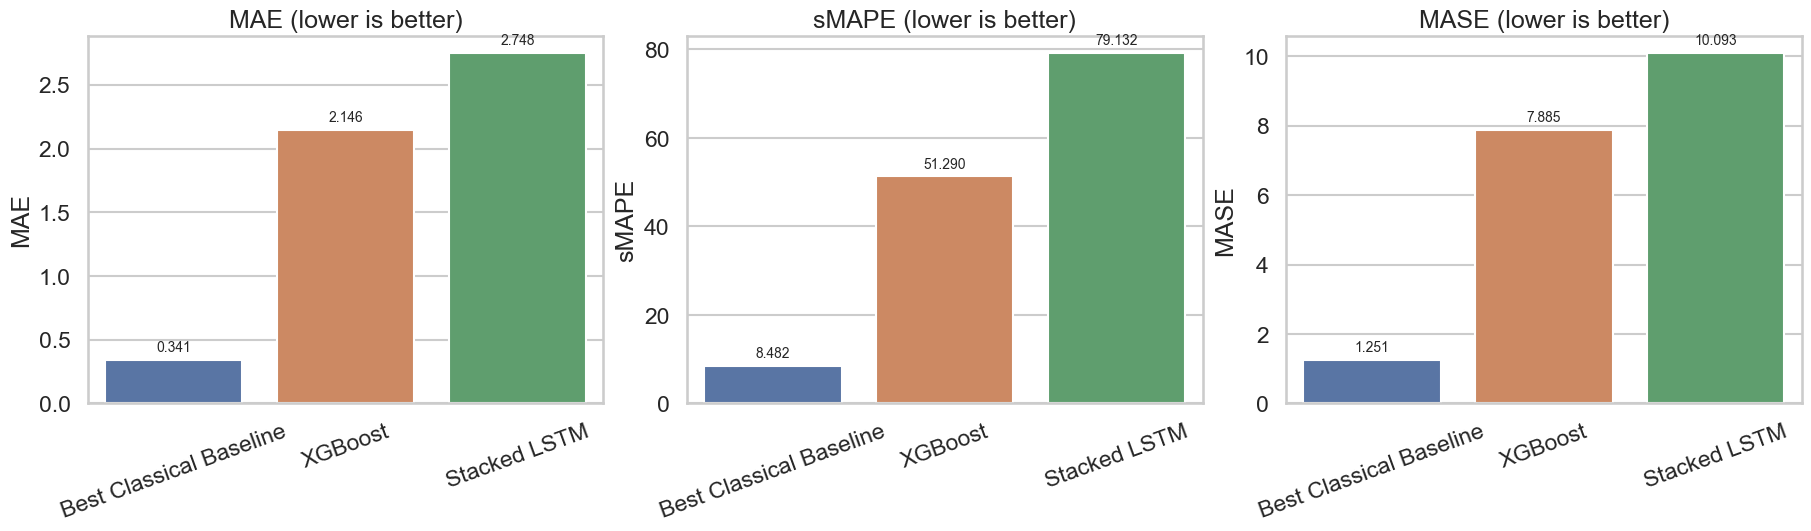

**Interpretation.** On the shared held-out window, **Best Classical Baseline (NaiveLast)** is best (MAE=0.3405, sMAPE=8.4818, MASE=1.2510). Its MAE is about **84.1%** lower than the second-best model on this same split.

Saved: C:\Users\User\Downloads\261-Project\results\final\figures\holdout_metric_comparison.png


In [5]:
holdout_df = comparison_df.loc[comparison_df["section"].isin(["Classical baselines", "LSTM", "XGBoost"])].copy()
name_map = {
    "Classical baselines": "Best Classical Baseline",
    "LSTM": "Stacked LSTM",
    "XGBoost": "XGBoost",
}
holdout_df["model_label"] = holdout_df["section"].map(name_map)

metric_specs = [
    ("mae", "MAE"),
    ("smape", "sMAPE"),
    ("mase", "MASE"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.2), constrained_layout=True)
for ax, (metric, label) in zip(axes, metric_specs):
    plot_df = holdout_df.sort_values(metric, ascending=True)
    sns.barplot(data=plot_df, x="model_label", y=metric, ax=ax, palette="deep")
    ax.set_title(f"{label} (lower is better)")
    ax.set_xlabel("")
    ax.set_ylabel(label)
    ax.tick_params(axis="x", rotation=20)
    for patch, value in zip(ax.patches, plot_df[metric].values):
        ax.annotate(f"{value:.3f}",
                    (patch.get_x() + patch.get_width() / 2, patch.get_height()),
                    ha="center", va="bottom", fontsize=10, xytext=(0, 4), textcoords="offset points")

holdout_plot_path = fig_dir / "holdout_metric_comparison.png"
fig.savefig(holdout_plot_path, dpi=170, bbox_inches="tight")
plt.show()

winner = holdout_df.sort_values("mae").iloc[0]
runner_up = holdout_df.sort_values("mae").iloc[1]
mae_adv_pct = 100.0 * (runner_up["mae"] - winner["mae"]) / runner_up["mae"]

display(Markdown(
    f"**Interpretation.** On the shared held-out window, **{name_map[winner['section']]} ({winner['entry']})** is best "
    f"(MAE={winner['mae']:.4f}, sMAPE={winner['smape']:.4f}, MASE={winner['mase']:.4f}). "
    f"Its MAE is about **{mae_adv_pct:.1f}%** lower than the second-best model on this same split."
))

print("Saved:", holdout_plot_path)


## 5) Figure: Rolling backtest stability summary (XGBoost)

This diagnostic shows temporal stability across walk-forward windows rather than one fixed split.


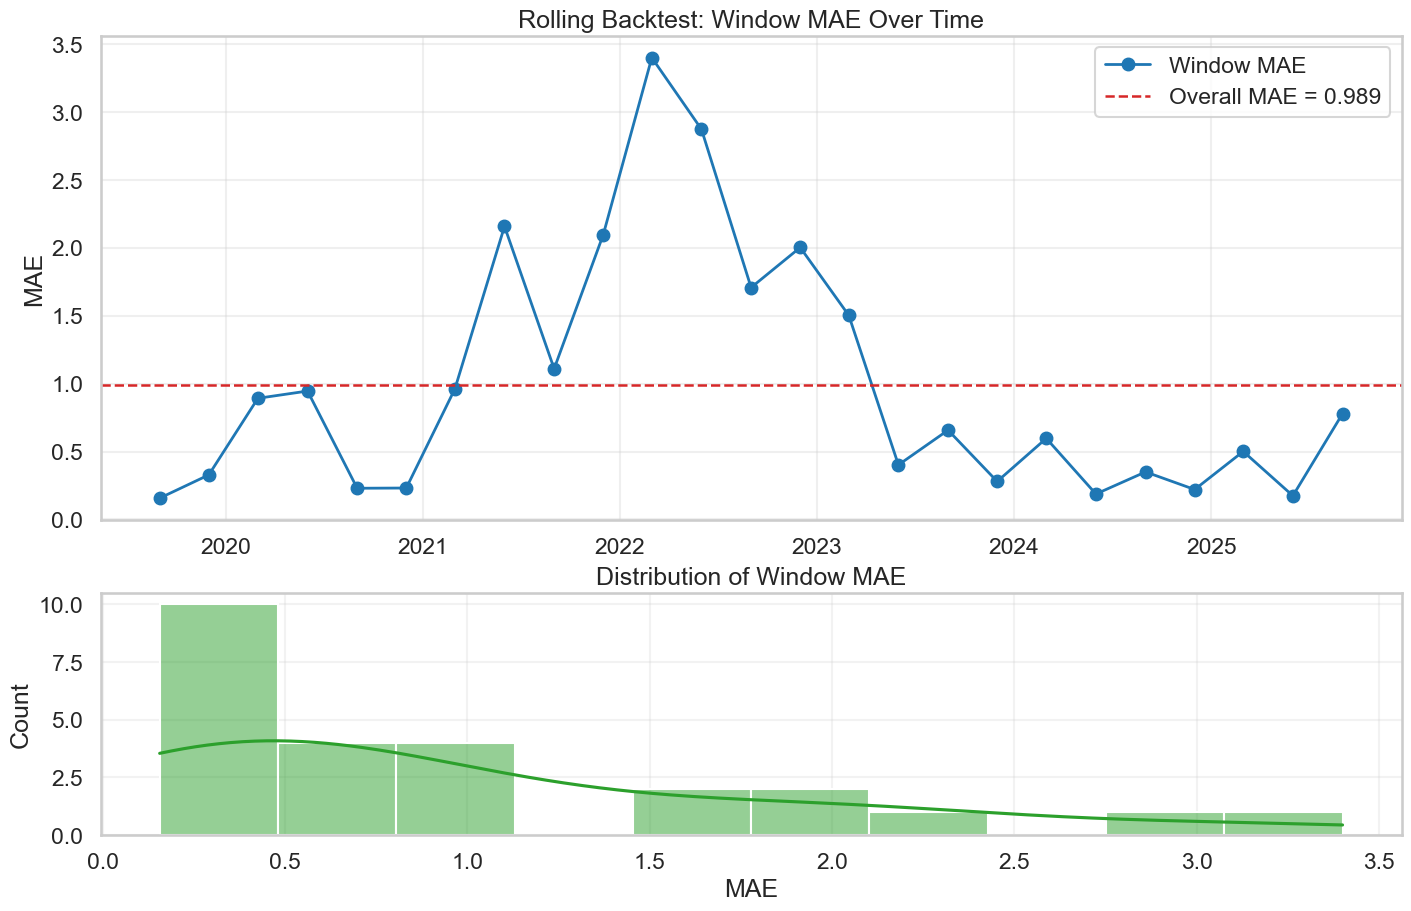

**Interpretation.** Backtest MAE ranges from **0.157** to **3.400**, with overall MAE **0.989** across 25 windows. Recent-window mean MAE (0.368) vs early-window mean MAE (0.464) highlights temporal variation in difficulty.

Saved: C:\Users\User\Downloads\261-Project\results\final\figures\rolling_backtest_summary.png


In [6]:
bt_df = backtest_windows_df.copy()
for c in ["test_start", "test_end", "train_end"]:
    bt_df[c] = pd.to_datetime(bt_df[c])

bt_df = bt_df.sort_values("window").reset_index(drop=True)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={"height_ratios": [2, 1]}, constrained_layout=True)

axes[0].plot(bt_df["test_end"], bt_df["mae"], marker="o", linewidth=2.0, color="#1f77b4", label="Window MAE")
axes[0].axhline(backtest_payload["overall"]["mae"], linestyle="--", color="#d62728", linewidth=1.8,
                label=f"Overall MAE = {backtest_payload['overall']['mae']:.3f}")
axes[0].set_title("Rolling Backtest: Window MAE Over Time")
axes[0].set_ylabel("MAE")
axes[0].grid(alpha=0.30)
axes[0].legend(loc="upper right")

sns.histplot(bt_df["mae"], bins=10, kde=True, ax=axes[1], color="#2ca02c")
axes[1].set_title("Distribution of Window MAE")
axes[1].set_xlabel("MAE")
axes[1].set_ylabel("Count")
axes[1].grid(alpha=0.25)

backtest_plot_path = fig_dir / "rolling_backtest_summary.png"
fig.savefig(backtest_plot_path, dpi=170, bbox_inches="tight")
plt.show()

worst_window = bt_df.sort_values("mae", ascending=False).iloc[0]
best_window = bt_df.sort_values("mae", ascending=True).iloc[0]

recent_mean = bt_df.tail(6)["mae"].mean()
early_mean = bt_df.head(6)["mae"].mean()

display(Markdown(
    f"**Interpretation.** Backtest MAE ranges from **{best_window['mae']:.3f}** to **{worst_window['mae']:.3f}**, "
    f"with overall MAE **{backtest_payload['overall']['mae']:.3f}** across {backtest_payload['n_windows']} windows. "
    f"Recent-window mean MAE ({recent_mean:.3f}) vs early-window mean MAE ({early_mean:.3f}) highlights temporal variation in difficulty."
))

print("Saved:", backtest_plot_path)


## 6) Figure: Uncertainty coverage calibration

Coverage is evaluated against the nominal target (`1 - alpha`).


C:\Users\User\AppData\Local\Temp\ipykernel_12752\3640538591.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coverage_df, x="method", y="coverage", ax=axes[0], palette="deep")
C:\Users\User\AppData\Local\Temp\ipykernel_12752\3640538591.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coverage_df, x="method", y="avg_width", ax=axes[1], palette="muted")


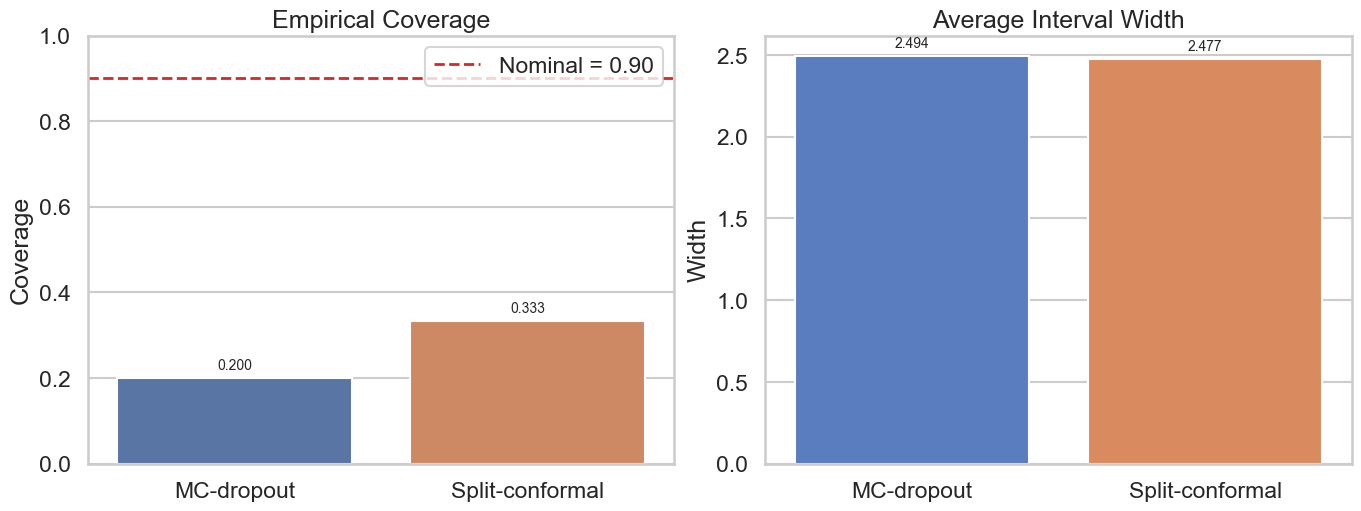

**Interpretation.** Both interval methods under-cover the target 90% nominal level. Coverage gaps are **0.700** (MC-dropout) and **0.567** (split-conformal), so uncertainty estimates are currently not well calibrated for decision-grade risk bounds.

Saved: C:\Users\User\Downloads\261-Project\results\final\figures\uncertainty_coverage_summary.png


In [7]:
nominal_cov = float(coverage_payload["nominal_coverage"])

coverage_df = pd.DataFrame([
    {
        "method": "MC-dropout",
        "coverage": float(coverage_payload["mc_dropout"]["empirical_coverage"]),
        "avg_width": float(coverage_payload["mc_dropout"]["avg_width"]),
    },
    {
        "method": "Split-conformal",
        "coverage": float(coverage_payload["split_conformal"]["empirical_coverage"]),
        "avg_width": float(coverage_payload["split_conformal"]["avg_width"]),
    },
])

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0), constrained_layout=True)

sns.barplot(data=coverage_df, x="method", y="coverage", ax=axes[0], palette="deep")
axes[0].axhline(nominal_cov, color="#d62728", linestyle="--", linewidth=2, label=f"Nominal = {nominal_cov:.2f}")
axes[0].set_title("Empirical Coverage")
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel("Coverage")
axes[0].set_xlabel("")
axes[0].legend(loc="upper right")
for patch, value in zip(axes[0].patches, coverage_df["coverage"].values):
    axes[0].annotate(f"{value:.3f}",
                     (patch.get_x() + patch.get_width() / 2, patch.get_height()),
                     ha="center", va="bottom", fontsize=10, xytext=(0, 4), textcoords="offset points")

sns.barplot(data=coverage_df, x="method", y="avg_width", ax=axes[1], palette="muted")
axes[1].set_title("Average Interval Width")
axes[1].set_ylabel("Width")
axes[1].set_xlabel("")
for patch, value in zip(axes[1].patches, coverage_df["avg_width"].values):
    axes[1].annotate(f"{value:.3f}",
                     (patch.get_x() + patch.get_width() / 2, patch.get_height()),
                     ha="center", va="bottom", fontsize=10, xytext=(0, 4), textcoords="offset points")

uncertainty_plot_path = fig_dir / "uncertainty_coverage_summary.png"
fig.savefig(uncertainty_plot_path, dpi=170, bbox_inches="tight")
plt.show()

mc_gap = nominal_cov - float(coverage_payload["mc_dropout"]["empirical_coverage"])
conf_gap = nominal_cov - float(coverage_payload["split_conformal"]["empirical_coverage"])

display(Markdown(
    f"**Interpretation.** Both interval methods under-cover the target 90% nominal level. "
    f"Coverage gaps are **{mc_gap:.3f}** (MC-dropout) and **{conf_gap:.3f}** (split-conformal), "
    f"so uncertainty estimates are currently not well calibrated for decision-grade risk bounds."
))

print("Saved:", uncertainty_plot_path)


## 7) Figure: Target-definition and lag sensitivity (ablation evidence)

This is used for limitation analysis and model-risk discussion, not to overwrite the main benchmark protocol.


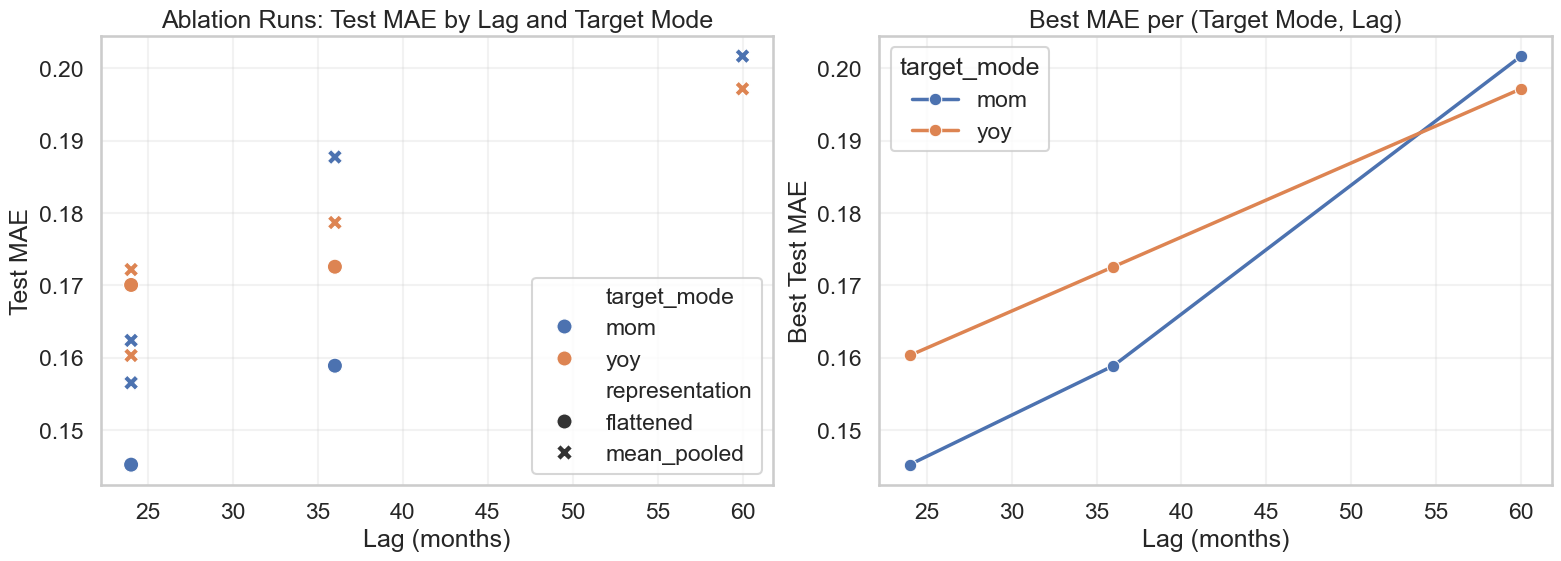

**Interpretation.** Ablation results show strong sensitivity to target definition and lag setup. Best run is `A9` with target `mom` and lag `24`. This reinforces that modeling conclusions depend materially on target specification choices.

Saved: C:\Users\User\Downloads\261-Project\results\final\figures\ablation_sensitivity_summary.png


In [8]:
ab_df = ablation_df.copy()

fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.5), constrained_layout=True)

sns.scatterplot(
    data=ab_df,
    x="lag",
    y="test_mae",
    hue="target_mode",
    style="representation",
    s=120,
    ax=axes[0],
)
axes[0].set_title("Ablation Runs: Test MAE by Lag and Target Mode")
axes[0].set_xlabel("Lag (months)")
axes[0].set_ylabel("Test MAE")
axes[0].grid(alpha=0.25)

summary_slice = (
    ab_df.groupby(["target_mode", "lag"], as_index=False)["test_mae"]
    .min()
    .sort_values(["target_mode", "lag"])
)

sns.lineplot(
    data=summary_slice,
    x="lag",
    y="test_mae",
    hue="target_mode",
    marker="o",
    linewidth=2.5,
    ax=axes[1],
)
axes[1].set_title("Best MAE per (Target Mode, Lag)")
axes[1].set_xlabel("Lag (months)")
axes[1].set_ylabel("Best Test MAE")
axes[1].grid(alpha=0.25)

ablation_plot_path = fig_dir / "ablation_sensitivity_summary.png"
fig.savefig(ablation_plot_path, dpi=170, bbox_inches="tight")
plt.show()

best_by_target = ab_df.groupby("target_mode", as_index=False)["test_mae"].min().sort_values("test_mae")

display(Markdown(
    "**Interpretation.** Ablation results show strong sensitivity to target definition and lag setup. "
    f"Best run is `{best_ablation['run_id']}` with target `{best_ablation['target_mode']}` and lag `{int(best_ablation['lag'])}`. "
    "This reinforces that modeling conclusions depend materially on target specification choices."
))

print("Saved:", ablation_plot_path)


## 8) Final winner, limitations, and report export

In [9]:
# Winner based on strict shared hold-out comparison
holdout_ranked = holdout_df.sort_values("mae").reset_index(drop=True)
final_winner = holdout_ranked.iloc[0]
second_best = holdout_ranked.iloc[1]

winner_label = name_map[final_winner["section"]]
winner_entry = str(final_winner["entry"])
winner_mae = float(final_winner["mae"])
winner_smape = float(final_winner["smape"])
winner_mase = float(final_winner["mase"])

margin_abs = float(second_best["mae"] - final_winner["mae"])
margin_pct = 100.0 * margin_abs / float(second_best["mae"])

# Copy selected legacy figures for final presentation bundle
presentation_copies = {
    "baseline_actual_vs_pred.png": ARTIFACTS["baseline_plot"],
    "lstm_actual_vs_pred.png": ARTIFACTS["lstm_plot"],
    "xgb_actual_vs_pred.png": ARTIFACTS["xgb_plot"],
    "xgb_feature_importance.png": ARTIFACTS["xgb_feature_importance_plot"],
    "uncertainty_intervals.png": ARTIFACTS["uncertainty_plot"],
}

copied_targets = []
for target_name, src_path in presentation_copies.items():
    dst = fig_dir / target_name
    shutil.copy2(src_path, dst)
    copied_targets.append(dst)

summary_lines = []
summary_lines.append("# Final Project Summary")
summary_lines.append("")
summary_lines.append(f"Generated UTC: {datetime.now(timezone.utc).isoformat()}")
summary_lines.append("")
summary_lines.append("## Final Winner")
summary_lines.append(
    f"The final winner on the shared held-out benchmark is **{winner_label} ({winner_entry})** with "
    f"MAE={winner_mae:.4f}, sMAPE={winner_smape:.4f}, and MASE={winner_mase:.4f}."
)
summary_lines.append(
    f"Its MAE margin over the second-best model is {margin_abs:.4f} ({margin_pct:.1f}%)."
)
summary_lines.append("")
summary_lines.append("## Why this winner")
summary_lines.append("- It is selected using the same held-out period used by both LSTM and XGBoost notebooks.")
summary_lines.append("- It dominates all three core error metrics (MAE, sMAPE, MASE) on that shared split.")
summary_lines.append("- More complex models did not translate into lower out-of-sample error in this setup.")
summary_lines.append("")
summary_lines.append("## Rolling Backtest and Uncertainty Diagnostics")
summary_lines.append(
    f"- XGBoost rolling backtest overall metrics: MAE={backtest_payload['overall']['mae']:.4f}, "
    f"sMAPE={backtest_payload['overall']['smape']:.4f}, MASE={backtest_payload['overall']['mase']:.4f} "
    f"across {int(backtest_payload['n_windows'])} windows."
)
summary_lines.append(
    f"- Uncertainty calibration is weak: MC-dropout coverage={coverage_payload['mc_dropout']['empirical_coverage']:.3f}, "
    f"split-conformal coverage={coverage_payload['split_conformal']['empirical_coverage']:.3f}, "
    f"vs nominal={coverage_payload['nominal_coverage']:.3f}."
)
summary_lines.append("")
summary_lines.append("## Limitations")
summary_lines.append("- **Small macro dataset**: monthly frequency and limited sample size constrain statistical power and deep-model reliability.")
summary_lines.append("- **Target-definition sensitivity**: ablations show substantial performance shifts across YoY vs MoM target formulations.")
summary_lines.append("- **Temporal instability**: rolling-window error varies across regimes, especially around macro turning points.")
summary_lines.append("- **Tree vs sequence limits**: tree models can miss temporal order effects; sequence models can overfit and be data-hungry in small samples.")
summary_lines.append("- **Uncertainty calibration caveats**: both MC-dropout and split-conformal intervals under-cover the nominal level, so risk bounds require recalibration.")
summary_lines.append("")
summary_lines.append("## Recommended next iteration")
summary_lines.append("- Revisit target engineering and interval calibration first, then re-evaluate whether complexity beats strong naive baselines.")

final_summary_path = final_dir / "final_summary.md"
final_summary_path.write_text(chr(10).join(summary_lines) + chr(10), encoding="utf-8")

print("Winner:", winner_label)
print("Saved:", final_summary_path)
print("Copied presentation figures:")
for p in copied_targets:
    print("-", p)


Winner: Best Classical Baseline
Saved: C:\Users\User\Downloads\261-Project\results\final\final_summary.md
Copied presentation figures:
- C:\Users\User\Downloads\261-Project\results\final\figures\baseline_actual_vs_pred.png
- C:\Users\User\Downloads\261-Project\results\final\figures\lstm_actual_vs_pred.png
- C:\Users\User\Downloads\261-Project\results\final\figures\xgb_actual_vs_pred.png
- C:\Users\User\Downloads\261-Project\results\final\figures\xgb_feature_importance.png
- C:\Users\User\Downloads\261-Project\results\final\figures\uncertainty_intervals.png


## 9) Final verification checks

In [10]:
required_final_outputs = [
    final_dir / "final_comparison_table.md",
    final_dir / "final_summary.md",
    fig_dir / "holdout_metric_comparison.png",
    fig_dir / "rolling_backtest_summary.png",
    fig_dir / "uncertainty_coverage_summary.png",
    fig_dir / "ablation_sensitivity_summary.png",
    fig_dir / "baseline_actual_vs_pred.png",
    fig_dir / "lstm_actual_vs_pred.png",
    fig_dir / "xgb_actual_vs_pred.png",
    fig_dir / "xgb_feature_importance.png",
    fig_dir / "uncertainty_intervals.png",
]

final_checks_df = pd.DataFrame([
    {"path": str(p.relative_to(ROOT)), "exists": p.exists()} for p in required_final_outputs
])

display(final_checks_df)

missing_final = final_checks_df.loc[~final_checks_df["exists"], "path"].tolist()
if missing_final:
    raise FileNotFoundError("Missing final outputs: " + ", ".join(missing_final))

# Quick content checks for exported markdown
comparison_text = (final_dir / "final_comparison_table.md").read_text(encoding="utf-8")
summary_text = (final_dir / "final_summary.md").read_text(encoding="utf-8")

assert "Final Comparison Table" in comparison_text
assert "Final Winner" in summary_text
assert "Limitations" in summary_text

print("All final output files exist.")
print("Markdown content checks passed.")
print("Notebook 08 report pipeline verification: PASS")


,path,exists
0,results\final\final_comparison_table.md,True
1,results\final\final_summary.md,True
2,results\final\figures\holdout_metric_compariso...,True
3,results\final\figures\rolling_backtest_summary...,True
4,results\final\figures\uncertainty_coverage_sum...,True
5,results\final\figures\ablation_sensitivity_sum...,True
6,results\final\figures\baseline_actual_vs_pred.png,True
7,results\final\figures\lstm_actual_vs_pred.png,True
8,results\final\figures\xgb_actual_vs_pred.png,True
9,results\final\figures\xgb_feature_importance.png,True


All final output files exist.
Markdown content checks passed.
Notebook 08 report pipeline verification: PASS


This notebook is intended to run top-to-bottom with no manual edits, using existing artifacts from notebooks 03-07.